In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('evaluation_results_24.csv')
df.head()

,patient_id,dsc,hd95,recall
0,BraTS-GLI-02799-100,0.4316,34.3256,0.3139
1,BraTS-GLI-00472-100,0.0000,NaN,0.0000
2,BraTS-GLI-02916-100,0.0000,74.1792,0.0000
3,BraTS-GLI-02740-100,0.6045,51.2967,0.8907
4,BraTS-GLI-02093-109,0.5600,10.0175,0.5490


In [ ]:
# df = df.round(4)

# df.to_csv('evaluation_results_24.csv', index=False)

In [6]:
metrics = df[['dsc', 'hd95', 'recall']]

summary_stats = metrics.describe().loc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
summary_stats = summary_stats.rename(index={
    'mean': 'Mean',
    'std': 'Standard Deviation',
    'min': 'Minimum',
    '25%': '25th Percentile',
    '50%': 'Median',
    '75%': '75th Percentile',
    'max': 'Maximum'
})

summary_stats.T

,Mean,Standard Deviation,Minimum,25th Percentile,Median,75th Percentile,Maximum
dsc,0.283155,0.265647,0.0000,0.0000,0.25155,0.521825,0.8960
hd95,48.728102,28.780702,3.1623,23.3409,47.02750,69.030400,137.2734
recall,0.336638,0.311988,0.0000,0.0000,0.30815,0.617850,1.0000


In [7]:
df.shape

(1350, 4)

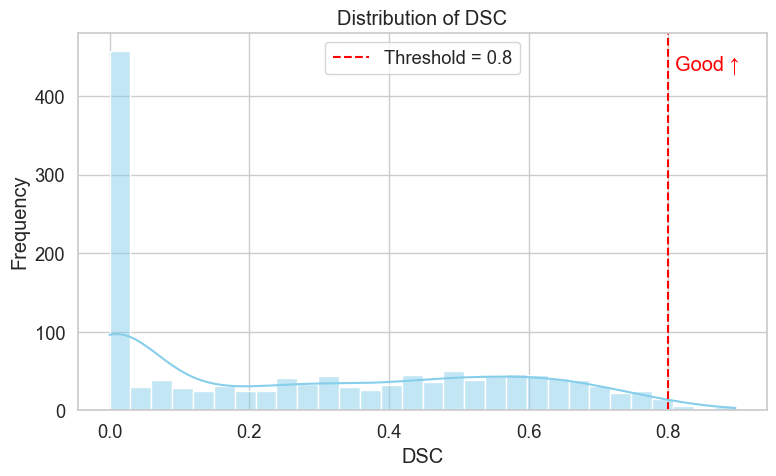

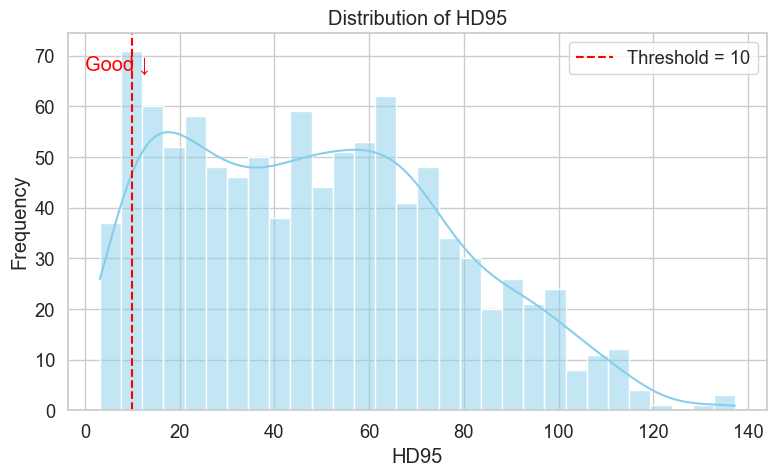

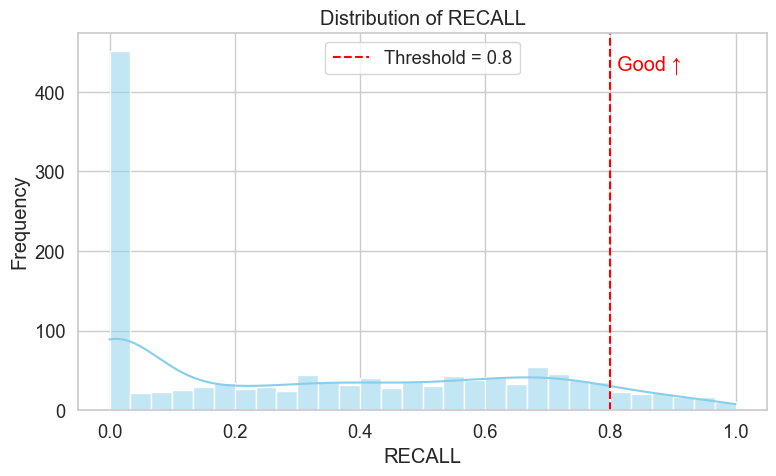

In [8]:
sns.set(style='whitegrid', palette='muted', font_scale=1.2)

def plot_metric(metric, threshold, good_direction='above'):
    plt.figure(figsize=(8, 5))
    sns.histplot(df[metric], bins=30, kde=True, color='skyblue')
    
    if good_direction == 'above':
        plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
        plt.text(threshold + 0.01, plt.ylim()[1]*0.9, 'Good ↑', color='red')
    else:
        plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
        plt.text(threshold - 10, plt.ylim()[1]*0.9, 'Good ↓', color='red')

    plt.title(f'Distribution of {metric.upper()}')
    plt.xlabel(metric.upper())
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_metric('dsc', threshold=0.8, good_direction='above')
plot_metric('hd95', threshold=10, good_direction='below')
plot_metric('recall', threshold=0.8, good_direction='above')

In [9]:
bad_rows = df[(df['dsc'] == 0) & (df['hd95'].isna()) & (df['recall'] == 0)]

count = len(bad_rows)

print(f"Total rows with dsc == 0, hd95 == NaN, recall == 0: {count}")

Total rows with dsc == 0, hd95 == NaN, recall == 0: 337
